# CSC4010Z Assignment 2: Encoder-Decoder Models for Grapheme-to-Phoneme Conversion

---

- **Author:** Siyabonga Madondo
- **Student Number:** MDNSIY014
- **Date:** 18 May 2026

---

A *grapheme* is the smallest unit of written language, while a *phoneme* is the smallest unit of sound in a language. Grapheme-to-Phoneme (G2P) conversion is the task of mapping written words to their pronunciation. G2P conversion is a core component of many systems, including text-to-speech (TTS) and automatic speech recognition (ASR), and can be framed as a sequence-to-sequence (Seq2Seq) task.

In this assignment, we implement an LSTM encoder-decoder model in three configurations:
1. Using no context vector
2. Using the final encoder hidden state $h_n$ as a context vector at every decoder step
3. Computing the context vector dynamically using *cross-attention* at every decoder step.

Using G2P conversion as the task, we train and evaluate each variant on the **CMU Pronouncing Dictionary (CMUdict)** to compare their performance. This allows us to observe the *hidden state bottleneck* and see how *attention* overcomes it.

**Generative AI Statement:**

# Setting Up
---

Package installations, imports, reproducibility seeds (42) and device configuration.

In [1]:
import os, sys, csv, random
from typing import Optional
from enum import Enum

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

# Check CUDA availability
if torch.cuda.is_available():
    device = torch.device('cuda')  
    torch.cuda.manual_seed_all(SEED)
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    torch.mps.manual_seed(SEED)
else:
    device = torch.device('cpu')

print(f"Python Version: {sys.version}\nPyTorch Version: {torch.__version__}\nUsing Device: {device}")

Python Version: 3.9.6 (default, Dec  2 2025, 07:27:58) 
[Clang 17.0.0 (clang-1700.6.3.2)]
PyTorch Version: 2.8.0
Using Device: mps


# 1. Dataset Processing
---

We use the **CMUdict** dataset, a lexicon of ~134,000 North American English words and their ARPAbet phoneme transcriptions. We use the following splits as specified in the guidelines:

| File | Words | Description |
|------|-------|-------------|
| `g2p_train.csv` | 92,426 | Training set |
| `g2p_val.csv` | 11,553 | Validation set |
| `g2p_test.csv` | 11,554 | Test set |

Each split is processed as follows:

1. Load words and phoneme sequences from the CSV file
2. Build character and phoneme vocabularies from the training split only
3. Encode each (word, phoneme) pair as integer index sequences, with `<SOS>` prepended and `<EOS>` appended to each target sequence

### Data Loading & Preprocessing

In [2]:
# Constant Values
SPECIAL_TOKENS = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']

def load_data(filepath: str):
    """Load a G2P CSV file, returning words and their phoneme sequences."""
    data = []
    
    # Check if the file exists
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset file not found: {filepath}")

    # Open and read the file
    with open(filepath, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            data.append(row)

    # Check if data successfully read
    if not data:
        raise ValueError(f"No data loaded from: {filepath}")
    
    # Extract all words and phonemes from the data
    words  = [entry['word'] for entry in data]
    phonemes = [entry['phonemes'].split() for entry in data]

    return words, phonemes

def build_character_vocabulary(words: list[str]):
    """Build the character vocabulary from the given list of words."""
    # Extract the characters from the word list and append the special tokens to the start
    characters = sorted(set(character for word in words for character in word))
    vocabulary = SPECIAL_TOKENS + characters

    # Map each character to an index and each index to a character
    character_to_index = {character: index for index, character in enumerate(vocabulary)}
    index_to_character = {index: character for character, index in character_to_index.items()}

    return character_to_index, index_to_character

def build_phoneme_vocabulary(phonemes: list[list[str]]):
    """Build the phoneme vocabulary from the given list of phonemes."""
    # Convert the list of phoneme sequences into a flat list of phonemes
    flat_phonemes = [phoneme for sequence in phonemes for phoneme in sequence]

    # Extract the phonemes from the phoneme list and append the special tokens to the start
    phonemes_sorted = sorted(set(flat_phonemes))
    vocabulary = SPECIAL_TOKENS + phonemes_sorted

    # Map each phoneme to a index and each index to a phoneme
    phoneme_to_index = {phoneme: index for index, phoneme in enumerate(vocabulary)}
    index_to_phoneme = {index: phoneme for phoneme, index in phoneme_to_index.items()}

    return phoneme_to_index, index_to_phoneme

# Load all splits
g2p_train_words, g2p_train_phonemes = load_data('../data/g2p_train.csv')
g2p_val_words, g2p_val_phonemes = load_data('../data/g2p_val.csv')
g2p_test_words, g2p_test_phonemes = load_data('../data/g2p_test.csv')

print("Datasets successfully loaded!")

# Build words and phoneme vocabularies for the training split
g2p_character_to_index, g2p_index_to_character = build_character_vocabulary(g2p_train_words)
g2p_phoneme_to_index, g2p_index_to_phoneme = build_phoneme_vocabulary(g2p_train_phonemes)

print("Word and phoneme vocabularies successfully initialised!")

Datasets successfully loaded!
Word and phoneme vocabularies successfully initialised!


### `G2PDataset` Class Definition

We define the `G2PDataset`, which encodes each G2P `(word, phoneme)` pair as integer index sequences. 

In [3]:
class G2PDataset(torch.utils.data.Dataset):
    """Dataset that encodes each G2P (word, phoneme) pair as integer index sequences."""

    def __init__(self, words: list[str], phonemes: list[list], g2p_character_to_index: dict[str, int], g2p_phoneme_to_index: dict[str, int]):
        """Initialise the G2PDataset with words, phoneme sequences, and vocabulary mappings."""
        self.words = words
        self.phonemes = phonemes
        self.character_to_index = g2p_character_to_index
        self.phoneme_to_index = g2p_phoneme_to_index

    def __getitem__(self, index: int):
        """Return the encoded (word, phoneme) pair at the given index as torch tensors."""
        # Obtain the word and its associated phoneme at the given index
        word = self.words[index]
        phonemes = self.phonemes[index]

        # Encode word characters as indices, with <EOS> appended
        unknown_index = self.character_to_index['<UNK>']
        word_indices = [self.character_to_index.get(character, unknown_index) for character in word]

        # Encode phoneme sequence with <SOS> prepended and <EOS> appended
        phoneme_indices = [self.phoneme_to_index['<SOS>']]
        phoneme_indices += [self.phoneme_to_index.get(phoneme, self.phoneme_to_index['<UNK>']) for phoneme in phonemes]
        phoneme_indices += [self.phoneme_to_index['<EOS>']]

        return torch.tensor(word_indices), torch.tensor(phoneme_indices)

    def __len__(self):
        "Return the number of samples in the dataset."
        return len(self.words)

### `DataLoaders` \& `collate_fn`

We implement `collate_fn` and use it to create `DataLoaders` with padded sequences in each batch.

In [4]:
# Constant Values
BATCH_SIZE = 64

def collate_fn(batch):
    """Pad word and phoneme sequences in a batch to the same length, with <PAD> = 0."""
    word_tensors, phoneme_tensors = zip(*batch)

    # Pad source (word) sequences to the longest word in the batch
    word_tensors_padded = pad_sequence(word_tensors, batch_first=True, padding_value=0)

    # Pad target (phoneme) sequences to the longest phoneme sequence
    phoneme_tensors_padded = pad_sequence(phoneme_tensors, batch_first=True, padding_value=0)

    return word_tensors_padded, phoneme_tensors_padded

# Create Datasets for each split 
g2p_train_dataset = G2PDataset(g2p_train_words, g2p_train_phonemes, g2p_character_to_index, g2p_phoneme_to_index)
g2p_val_dataset = G2PDataset(g2p_val_words, g2p_val_phonemes, g2p_character_to_index, g2p_phoneme_to_index)
g2p_test_dataset = G2PDataset(g2p_test_words, g2p_test_phonemes, g2p_character_to_index, g2p_phoneme_to_index)
print("Datasets created successfully!")

# Create Data Loaders for each split
g2p_train_loader = DataLoader(g2p_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
g2p_val_loader = DataLoader(g2p_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
g2p_test_loader = DataLoader(g2p_test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print("Data Loaders created successfully!")


Datasets created successfully!
Data Loaders created successfully!


### Data Exploration

Character vocabulary size : 30
Phoneme vocabulary size   : 73
Train samples: 92426
Validation samples  : 11553
Test samples : 11554


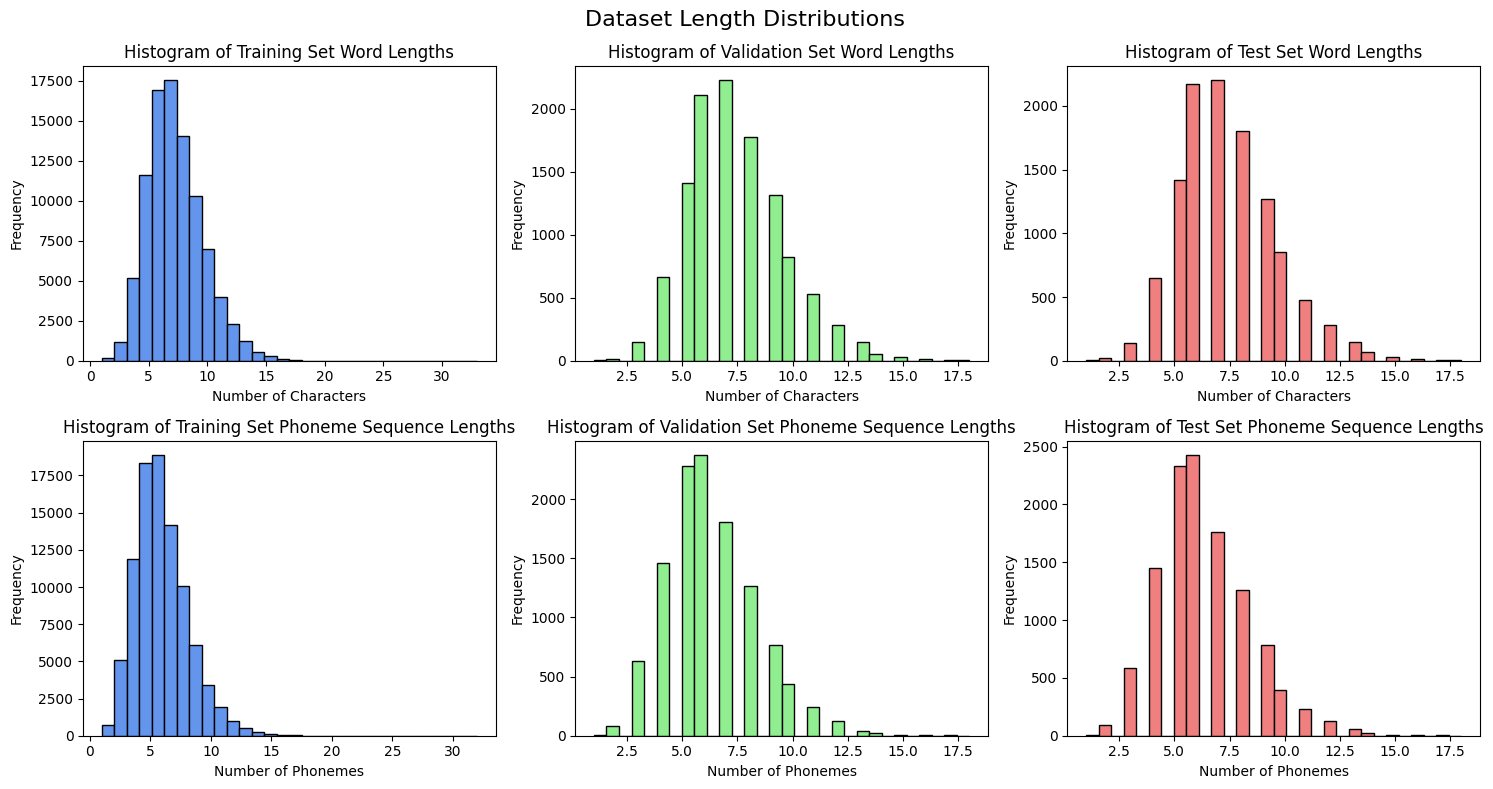

In [5]:
# Vocabulary & dataset sizes
print(f"Character vocabulary size : {len(g2p_character_to_index)}")
print(f"Phoneme vocabulary size   : {len(g2p_phoneme_to_index)}")
print(f"Train samples: {len(g2p_train_dataset)}")
print(f"Validation samples  : {len(g2p_val_dataset)}")
print(f"Test samples : {len(g2p_test_dataset)}")

# Compute lengths
train_word_lengths = [len(word) for word in g2p_train_words]
val_word_lengths = [len(word) for word in g2p_val_words]
test_word_lengths = [len(word) for word in g2p_test_words]

train_phoneme_lengths = [len(phoneme) for phoneme in g2p_train_phonemes]
val_phoneme_lengths   = [len(phoneme) for phoneme in g2p_val_phonemes]
test_phoneme_lengths  = [len(phoneme) for phoneme in g2p_test_phonemes]

# Plot histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

fig.suptitle('Dataset Length Distributions', fontsize=16)

axes[0, 0].hist(train_word_lengths, bins=30, color='cornflowerblue', edgecolor='black')
axes[0, 1].hist(val_word_lengths,   bins=30, color='lightgreen', edgecolor='black')
axes[0, 2].hist(test_word_lengths,  bins=30, color='lightcoral', edgecolor='black')

axes[1, 0].hist(train_phoneme_lengths, bins=30, color='cornflowerblue', edgecolor='black')
axes[1, 1].hist(val_phoneme_lengths,   bins=30, color='lightgreen', edgecolor='black')
axes[1, 2].hist(test_phoneme_lengths,  bins=30, color='lightcoral', edgecolor='black')

# Add axis labels
for col, split in enumerate(['Training', 'Validation', 'Test']):
    axes[0, col].set_title(f'Histogram of {split} Set Word Lengths')
    axes[0, col].set_xlabel('Number of Characters')
    axes[0, col].set_ylabel('Frequency')

    axes[1, col].set_title(f'Histogram of {split} Set Phoneme Sequence Lengths')
    axes[1, col].set_xlabel('Number of Phonemes')
    axes[1, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 2. LSTM Cell Implementation
---

Unlike a standard RNN, the **LSTM cell** maintains two states across timesteps: a hidden state, $h_t$ and a cell state $c_t$. These are controlled by *input, forget, and output gates*, which control information flow. We implement an LSTM cell from scratch in the `LSTMCell` class.

In [6]:
class LSTMCell(nn.Module):
    """LSTM cell implementing the six LSTM gating equations."""

    def __init__(self, input_size: int, hidden_size: int, context: bool = False):
        """
        Initialise the LSTM cell and its parameters.

        :param input_size: Dimensionality of input x_t
        :param hidden_size: Dimensionality of hidden state h_t and cell state c_t
        :param context: Specifies whether to initialise context projection matrices V
        """
        super().__init__()
        self.hidden_size = hidden_size
        
        # Forget gate
        self.W_f = nn.Linear(input_size, hidden_size, bias=False)
        self.U_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_f = nn.Parameter(torch.zeros(hidden_size))
    
        # Input gate
        self.W_i = nn.Linear(input_size, hidden_size, bias=False)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_i = nn.Parameter(torch.zeros(hidden_size))
       
        # Output gate
        self.W_o = nn.Linear(input_size, hidden_size, bias=False)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_o = nn.Parameter(torch.zeros(hidden_size))
       
        # Cell content
        self.W_c = nn.Linear(input_size, hidden_size, bias=False)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_c = nn.Parameter(torch.zeros(hidden_size))

        # Context projection matrices V for projecting context vector z into each gate
        if context:
            self.V_f = nn.Linear(hidden_size, hidden_size, bias=False)
            self.V_i = nn.Linear(hidden_size, hidden_size, bias=False)
            self.V_o = nn.Linear(hidden_size, hidden_size, bias=False)
            self.V_c = nn.Linear(hidden_size, hidden_size, bias=False)
  
    def forward(self, x: torch.Tensor, h_prev: torch.Tensor, c_prev: torch.Tensor, z: Optional[torch.Tensor] = None):
        """
        Compute one LSTM timestep.

        :param x: Input at the current timestep, shape (batch, input_size)
        :param h_prev: Previous hidden state, shape (batch, hidden_size)
        :param c_prev: Previous cell state, shape (batch, hidden_size)
        :param z: Optional context vector, shape (batch, hidden_size), projected into each gate using the V matrices. 
        :returns: New hidden state h and cell state c, each of shape (batch, hidden_size)
        """
        # Compute the context projection if required.
        v_f = self.V_f(z) if z is not None else 0
        v_i = self.V_i(z) if z is not None else 0
        v_o = self.V_o(z) if z is not None else 0
        v_c = self.V_c(z) if z is not None else 0

        # Gate computations
        f = torch.sigmoid(self.W_f(x) + self.U_f(h_prev) + v_f + self.b_f)
        i = torch.sigmoid(self.W_i(x) + self.U_i(h_prev) + v_i + self.b_i)
        o = torch.sigmoid(self.W_o(x) + self.U_o(h_prev) + v_o + self.b_o)
        c_tilde = torch.tanh(self.W_c(x) + self.U_c(h_prev) + v_c + self.b_c)
        c = f * c_prev + i * c_tilde
        h = o * torch.tanh(c)

        return h, c

# 3. Encoder-Decoder Implementation
---

We now implement the encoder and decoder components of the LSTM encoder-decoder model.

### `Encoder` Class Definition
---

We implement our encoder as an LSTM that processes the input sequence $x_1, \ldots, x_n$ and produces final hidden and cell states, $h_n^{enc}$ and $c_n^{enc}$. These states are then passed to the decoder as its initial hidden and cell states.

In [7]:
class Encoder(nn.Module):
    """LSTM encoder that processes an input sequence and produces a final hidden and cell state."""

    def __init__(self, src_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1): 
        """
        Initialise the LSTM encoder and its cells.
        
        :param src_vocab_size: number of tokens in the source (character) vocabulary
        :param embed_dim: dimensionality of the character embeddings
        :param hidden_size: dimensionality of the LSTM hidden and cell states
        :param num_layers: number of LSTM layers
        """
        super().__init__()

        # Initialise embeddings, hidden size and number of layers
        self.embeddings = nn.Embedding(src_vocab_size, embed_dim)
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Initialise the encoder LSTM cells
        self.cells = nn.ModuleList(
            LSTMCell(embed_dim if layer == 0 else hidden_size, hidden_size)
            for layer in range(num_layers)
        )

    def forward(self, src: torch.Tensor):
        """
        Encode the source sequence.

        :param src: Input token indices, shape (batch, src_len)
        :returns: Tuple of all_h, (h_n, c_n)
        """
        batch_size, src_len = src.shape

        # Look up the source embeddings
        src_embeddings = self.embeddings(src)

        # Initialise the hidden and cell state tensors to zero for every layer
        h = [torch.zeros(batch_size, self.hidden_size, device=src.device) 
             for _ in range(self.num_layers)]
        c = [torch.zeros(batch_size, self.hidden_size, device=src.device)
                for _ in range(self.num_layers)]
        
        # Initialise the hidden states and compute values across all timesteps t  
        all_h = []

        for timestep in range(src_len):
            # Obtain the input x_t from the source embeddings
            x_t = src_embeddings[:, timestep,:]

            # Pass x_t through each layer
            for layer, cell in enumerate(self.cells):
                # Pass this layer's hidden state as input to the next layer
                h[layer], c[layer] = cell(x_t, h[layer], c[layer])
                x_t = h[layer]

            # Add the final layer's hidden state at timestep t to the state list
            final_h = h[-1]
            all_h.append(final_h)
            
        # Stack hidden states into a single tensor
        all_h = torch.stack(all_h, dim=0)
        h_n = torch.stack(h, dim=0)
        c_n = torch.stack(c, dim=0)

        return all_h, (h_n, c_n)

### `CrossAttention` Class Definition

---

Before implementing the decoder, we define the cross-attention mechanism used in the `ATTENTION` context mode.

In [8]:
class CrossAttention(nn.Module):
    """Dot-product cross-attention that attends over encoder hidden states to produce a context vector."""

    def __init__(self):
        """Initialise the cross attention."""
        super().__init__()

    def forward(self, query: torch.Tensor, encoder_outputs: torch.Tensor):
        """
        Compute the context vector for one decoder timestep.

        :param query: Decoder hidden state, shape (batch, hidden_size)
        :param encoder_outputs: All encoder hidden states, shape (src_len, batch, hidden_size)
        :returns: Tuple of context vector z_t (batch, hidden_size) and attention weights (batch, src_len)
        """
        # Rearrange outputs to match dimensions
        outputs = encoder_outputs.permute(1, 0, 2)
        query = query.unsqueeze(1)

        # Compute scores using batched dot-product
        scores = torch.bmm(query, outputs.transpose(1, 2))

        # Normalise using softmax to get attention weights
        weights = F.softmax(scores, dim=-1)

        # Compute the batched weighted sum of the encoder outputs and the weights
        z_t = torch.bmm(weights, outputs).squeeze(1)
        weights = weights.squeeze(1)

        return z_t, weights

### `Decoder` Class Definition

We implement the decoder as an LSTM that uses one of three context modes $c \in$ $\{$`NONE`, `FIXED`, `ATTENTION`$\}$, represented as the enum `ContextMode`:

1. `NONE`: no context vector; the decoder is initialised with $(h_n^{enc}, c_n^{enc})$ and receives no encoder information at subsequent steps.
2. `FIXED`: a fixed context vector $z = h_n^{enc}$ is concatenated to the decoder input at every step.
3. `ATTENTION`: a dynamic context vector $z_t$ is computed at every step by attending over all encoder hidden states using `CrossAttention`.

In [9]:
class ContextMode(Enum):
    """Represents a Decoder context mode."""
    NONE = "none"
    FIXED = "fixed"
    ATTENTION = "attention"

class Decoder(nn.Module):
    """LSTM decoder that processes one input token at a time and produces output logits and updated states."""

    def __init__(self, tgt_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1, context_mode: ContextMode = ContextMode.NONE):
        """
        Initialise the LSTM decoder and its cells.
        
        :param tgt_vocab_size: number of tokens in the target (phoneme) vocabulary
        :param embed_dim: dimensionality of the phoneme embeddings
        :param hidden_size: dimensionality of the LSTM hidden and cell states
        :param num_layers: number of LSTM layers
        :param context_mode: context mode to initialise the decoder in
        """
        super().__init__()    
        
        # Initialise embeddings, hidden size, number of layers, and context mode
        self.embeddings = nn.Embedding(tgt_vocab_size, embed_dim)
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.context_mode = context_mode
        self.fc = nn.Linear(hidden_size, tgt_vocab_size)

        # Initialise the attention module when required
        if context_mode == ContextMode.ATTENTION:
            self.attention = CrossAttention()

        # Initialise the decoder LSTM cells (Only add context for the first layer if required)
        self.cells = nn.ModuleList(
            LSTMCell(embed_dim if layer == 0 else hidden_size, 
                     hidden_size, 
                     context=context_mode != ContextMode.NONE and layer == 0
            )
            for layer in range(num_layers)
        )

    def forward(self, tgt: torch.Tensor, hidden: tuple[torch.Tensor, torch.Tensor], encoder_outputs: Optional[torch.Tensor] = None):
        """
        Run one forward pass over the target sequence.

        :param tgt: Target token indices, shape (batch, tgt_len).
        :param hidden: Initial decoder states (h_0, c_0), each of shape (num_layers, batch, hidden_size).
        :param encoder_outputs: All encoder hidden states, shape (src_len, batch, hidden_size). Only required for ATTENTION mode.
        :returns: Tuple of logits, (h_n, c_n)
        """
        _, tgt_len = tgt.shape
        
        # Look up the target embeddings
        tgt_embeddings = self.embeddings(tgt)

        # Initialise the hidden and cell state tensors for each layer
        h_0, c_0 = hidden
        h = [h_0[layer] for layer in range(self.num_layers)]
        c = [c_0[layer] for layer in range(self.num_layers)]

        # Collect logits across all timesteps
        logits = []

        for timestep in range(tgt_len):
            # Obtain the input x_t from the target embeddings
            x_t = tgt_embeddings[:, timestep,:]
        
            # Compute the context vector z as required  
            if self.context_mode == ContextMode.FIXED:
                z = encoder_outputs[-1] #type: ignore
            elif self.context_mode == ContextMode.ATTENTION:
                z, _ = self.attention(h[-1], encoder_outputs)
            else:
                z = None
            
            # Pass context vector z into the cells in the input layer
            h[0], c[0] = self.cells[0](x_t, h[0], c[0], z=z)
            x_t = h[0]

            for layer in range(1, self.num_layers):
                # Pass this layer's hidden state as input to the next layer
                h[layer], c[layer] = self.cells[layer](x_t, h[layer], c[layer])
                x_t = h[layer]

            # Compute and add the final layer's logit value to the logits list
            logit = self.fc(h[-1])
            logits.append(logit)

        # Stack logits and hidden states into a single tensor
        logits = torch.stack(logits, dim=1)
        h_n = torch.stack(h, dim=0)
        c_n = torch.stack(c, dim=0)

        return logits, (h_n, c_n)

### Seq2Seq Implementation

